# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


# Assignment 4.5
## Exploring the Factors That Influence Google Play Store Application Popularity

**Gregory Hudler**

For this assignment, I analyzed a dataset containing information about applications published on the Google Play Store. The objective is to identify which application characteristics appear to have the strongest relationship with application popularity, measured by the number of installs.

### Target Feature

The target feature for this analysis is **Installs_Numeric**, which represents the total number of installs for each application. This feature was selected because it serves as a direct measure of an application's popularity on the Google Play Store.

### Features Analyzed

The following application characteristics were compared to the target feature:

- **Category** – The type of application (Games, Business, Education, Tools, etc.)
- **Rating** – The average user rating on a scale from 1.0 to 5.0.
- **Reviews** – The total number of user reviews submitted for the application.
- **Type** – Whether the application is Free or Paid.
- **Price** – The cost of the application in U.S. dollars.
- **Content Rating** – The intended audience of the application (Everyone, Teen, Mature 17+, etc.).

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
apps_df = pd.read_csv("googleplaystore.csv")
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [4]:
apps_df.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Cleaning

The original dataset contains 10,841 Google Play Store app records and 13 columns. Several columns were stored as text even though they represent numeric values. For example, the `Installs` column contains commas and plus signs, the `Price` column contains dollar signs, and the `Reviews` column is stored as text.

To prepare the dataset for analysis, I created a cleaned copy of the original DataFrame. The selected numeric columns were converted into appropriate data types, duplicate applications were removed, and rows with missing values in the selected analysis columns were excluded.

In [6]:
apps_clean_df = apps_df.copy()

In [7]:
# Remove commas and + from Installs
apps_clean_df["Installs_Numeric"] = (
    apps_clean_df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps_clean_df["Installs_Numeric"] = pd.to_numeric(
    apps_clean_df["Installs_Numeric"],
    errors="coerce"
)

# Reviews
apps_clean_df["Reviews"] = pd.to_numeric(
    apps_clean_df["Reviews"],
    errors="coerce"
)

# Price
apps_clean_df["Price"] = (
    apps_clean_df["Price"]
    .str.replace("$", "", regex=False)
)

apps_clean_df["Price"] = pd.to_numeric(
    apps_clean_df["Price"],
    errors="coerce"
)

# Rating
apps_clean_df["Rating"] = pd.to_numeric(
    apps_clean_df["Rating"],
    errors="coerce"
)

In [8]:
apps_clean_df = apps_clean_df.drop_duplicates(subset="App")

apps_clean_df = apps_clean_df.dropna(
    subset=[
        "Rating",
        "Installs_Numeric",
        "Reviews",
        "Price"
    ]
)

## Verify the Cleaned Dataset

After cleaning the data, the dataset is examined again to verify that the selected variables have been converted into the correct data types and that missing values have been removed from the columns used in this analysis.

In [12]:
apps_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8196 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               8196 non-null   object 
 1   Category          8196 non-null   object 
 2   Rating            8196 non-null   float64
 3   Reviews           8196 non-null   float64
 4   Size              8196 non-null   object 
 5   Installs          8196 non-null   object 
 6   Type              8196 non-null   object 
 7   Price             8196 non-null   float64
 8   Content Rating    8196 non-null   object 
 9   Genres            8196 non-null   object 
 10  Last Updated      8196 non-null   object 
 11  Current Ver       8192 non-null   object 
 12  Android Ver       8194 non-null   object 
 13  Installs_Numeric  8196 non-null   float64
dtypes: float64(4), object(10)
memory usage: 960.5+ KB


In [13]:
apps_clean_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Numeric
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,"10,000+",Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,10000.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,"500,000+",Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,"5,000,000+",Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,5000000.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,"50,000,000+",Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,50000000.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,"100,000+",Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,100000.0


In [14]:
apps_clean_df.describe()

,Rating,Reviews,Price,Installs_Numeric
count,8196.000000,8.196000e+03,8196.000000,8.196000e+03
mean,4.173243,2.552515e+05,1.037884,9.165090e+06
std,0.536625,1.985594e+06,16.857882,5.825087e+07
min,1.000000,1.000000e+00,0.000000,1.000000e+00
25%,4.000000,1.260000e+02,0.000000,1.000000e+04
50%,4.300000,3.004000e+03,0.000000,1.000000e+05
75%,4.500000,4.381300e+04,0.000000,1.000000e+06
max,5.000000,7.815831e+07,400.000000,1.000000e+09


In [10]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

## Target Variable and Selected Features

The objective of this analysis is to determine which application characteristics appear to influence the popularity of Google Play Store applications.

### Target Feature

The target feature selected for this analysis is **Installs_Numeric**, which represents the total number of installs for each application after converting the original text values into numeric values.

### Selected Features

The following features will be compared to the target:

- **Category** – The type of application (Games, Business, Education, etc.)
- **Rating** – Average user rating from 1.0 to 5.0
- **Reviews** – Total number of user reviews
- **Type** – Whether the application is Free or Paid
- **Price** – Cost of the application in U.S. dollars
- **Content Rating** – Intended audience (Everyone, Teen, Mature 17+, etc.)

These features were selected because they describe an application's market, pricing strategy, user engagement, and audience, all of which may influence application popularity.

## Exploratory Data Analysis

## Distribution of Application Installs

Before comparing application characteristics to the target variable, it is useful to understand how installs are distributed throughout the dataset.

The histogram below illustrates the overall distribution of application installs after converting the original install counts into numeric values. Because install counts range from a single download to over one billion downloads, a logarithmic scale is used to make the distribution easier to interpret.

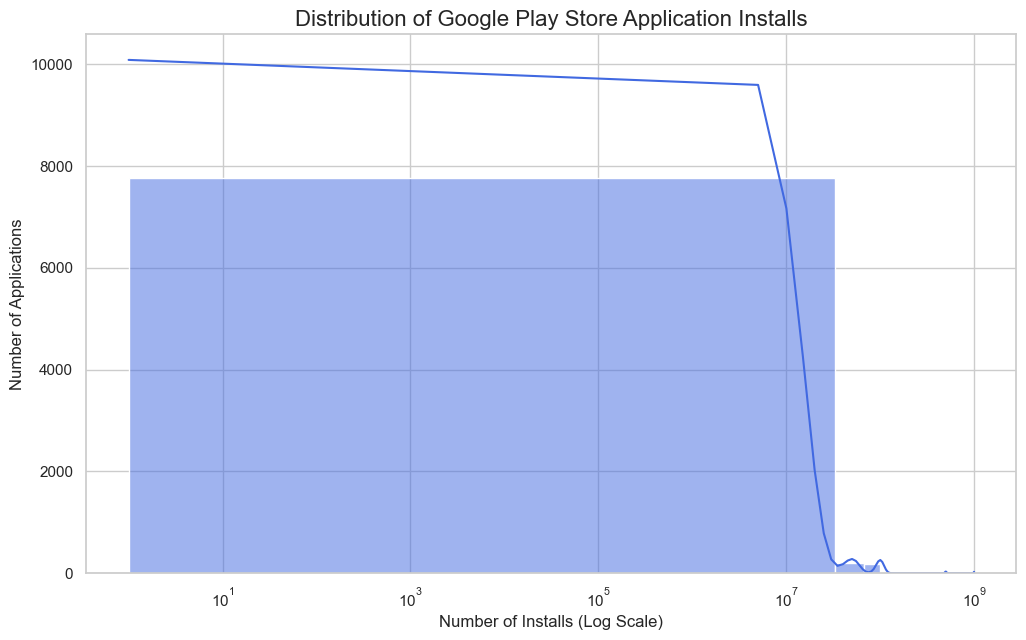

In [15]:
plt.figure(figsize=(12,7))

sns.histplot(
    data=apps_clean_df,
    x="Installs_Numeric",
    bins=30,
    kde=True,
    color="royalblue"
)

plt.xscale("log")

plt.title("Distribution of Google Play Store Application Installs")

plt.xlabel("Number of Installs (Log Scale)")
plt.ylabel("Number of Applications")

plt.show()

### Interpretation

The distribution shows that the majority of applications receive relatively few installs, while only a small number of applications achieve extremely large download counts. This creates a heavily right-skewed distribution, which is common for digital products where a small percentage of applications become exceptionally popular while most remain within smaller user bases.

Because of this large variation in install counts, the remaining visualizations will frequently use a logarithmic scale to improve readability and allow meaningful comparisons between application categories.

## Relationship Between App Category and Application Installs

One of the most important questions for mobile application developers is whether certain categories consistently receive more downloads than others.

The boxplot below compares the distribution of installs for every Google Play Store category. Each category is displayed with a different color and ordered from the highest median number of installs to the lowest. Because install counts span several orders of magnitude, a logarithmic scale is used to improve readability.

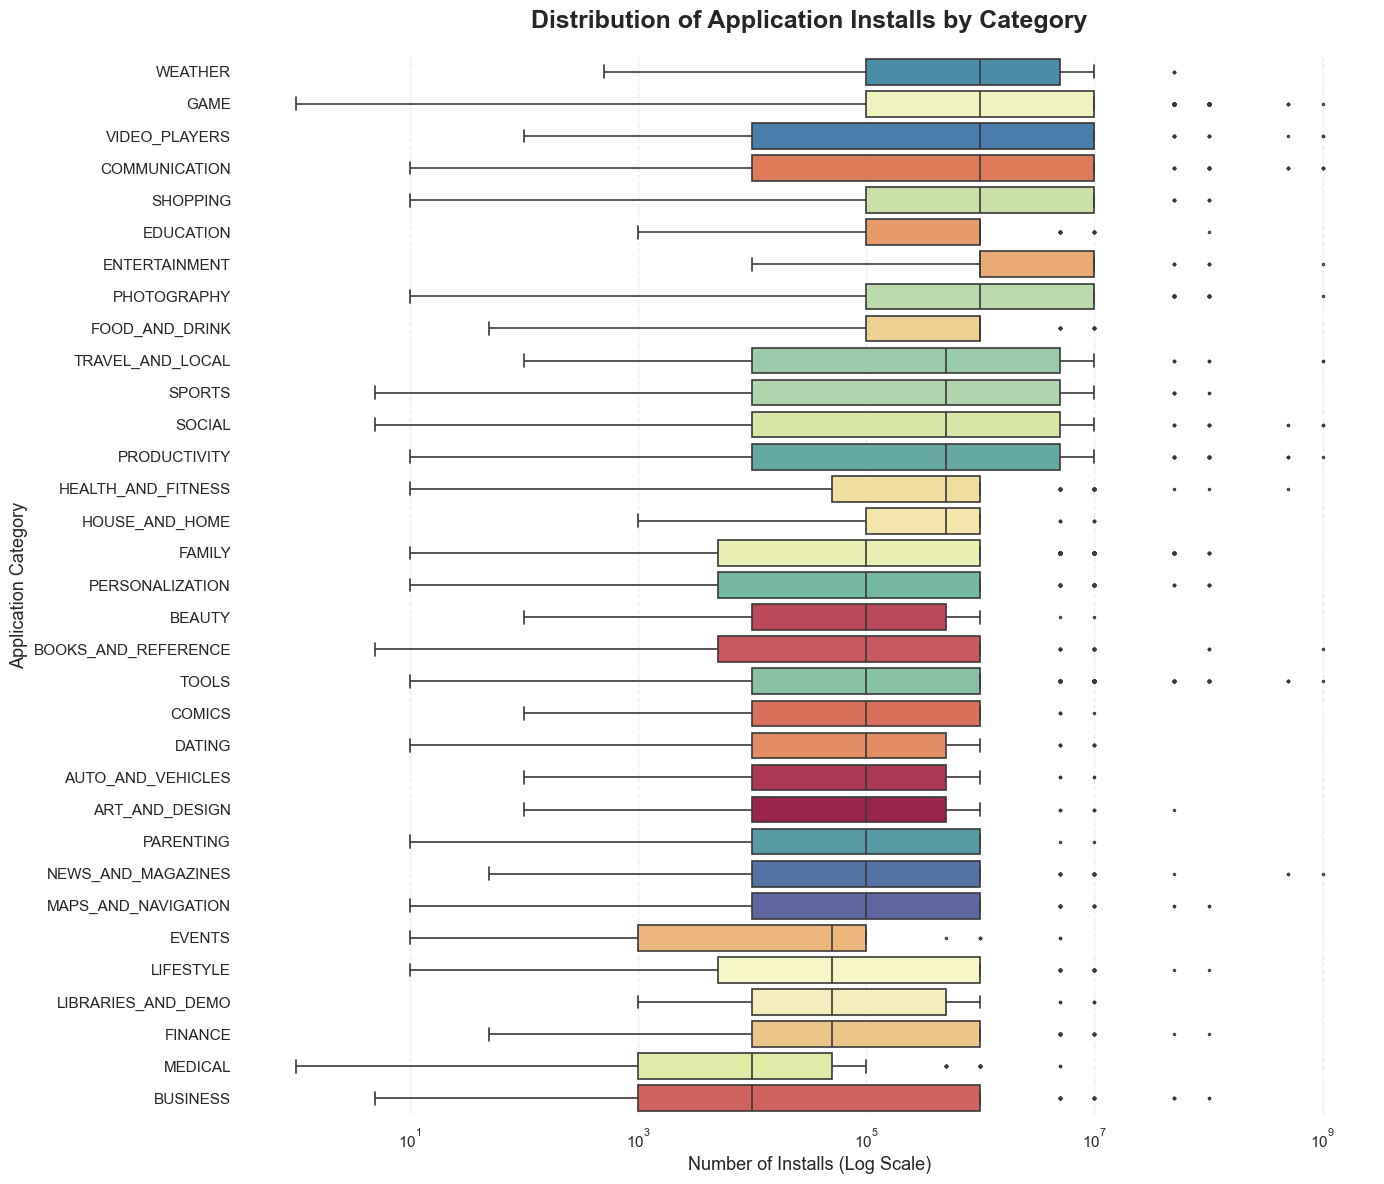

In [17]:
category_order = (
    apps_clean_df.groupby("Category")["Installs_Numeric"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14, 12))

ax = sns.boxplot(
    data=apps_clean_df,
    x="Installs_Numeric",
    y="Category",
    order=category_order,
    hue="Category",
    palette="Spectral",
    linewidth=1.2,
    fliersize=1.5,
    dodge=False,
    legend=False
)

ax.set_xscale("log")

plt.title(
    "Distribution of Application Installs by Category",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Number of Installs (Log Scale)", fontsize=13)
plt.ylabel("Application Category", fontsize=13)

plt.grid(axis="x", linestyle="--", alpha=0.35)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Interpretation

The visualization shows that application category has a noticeable relationship with the number of installs. Categories such as Communication, Video Players, Social, and Productivity tend to have much higher average install counts than many of the more specialized categories. This suggests that applications designed for broad, everyday use generally reach larger audiences.

At the same time, the differences between categories indicate that popularity is not determined by category alone. While choosing a popular category may increase the potential audience, other factors such as application quality, user ratings, pricing strategy, and user engagement also play an important role in determining how successful an application becomes on the Google Play Store.

Overall, application category appears to be one of the strongest predictors of install count observed so far and will serve as a useful comparison when examining the remaining application features.

## Visualization 3: Median Number of Installs by Application Category

The previous visualization illustrated the distribution of installs within each application category. While the boxplots provided insight into the spread and variability of install counts, they did not clearly identify which categories typically receive the most installs.

This visualization compares the **median** number of installs for each application category. The median is used instead of the average because it is less affected by a small number of extremely popular applications and better represents the typical application within each category. By ranking the categories from highest to lowest median installs, it becomes easier to identify which categories consistently achieve the greatest level of popularity on the Google Play Store.

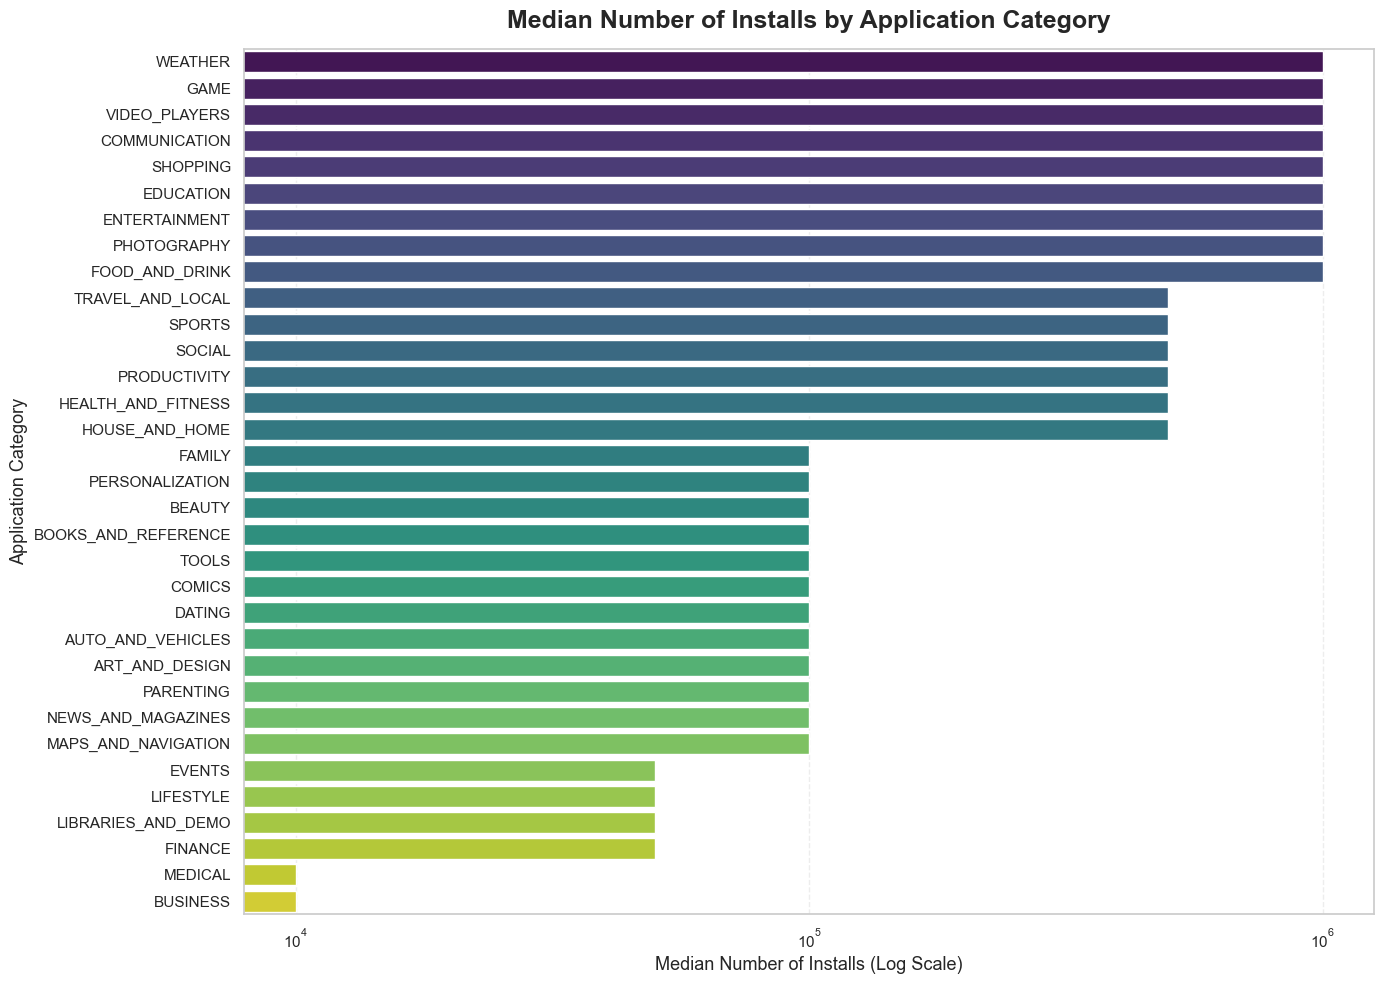

In [18]:
# Calculate the median installs for each category
median_installs = (
    apps_clean_df.groupby("Category")["Installs_Numeric"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 10))

ax = sns.barplot(
    x=median_installs.values,
    y=median_installs.index,
    hue=median_installs.index,
    palette="viridis",
    legend=False
)

plt.xscale("log")

plt.title(
    "Median Number of Installs by Application Category",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Median Number of Installs (Log Scale)", fontsize=13)
plt.ylabel("Application Category", fontsize=13)

plt.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()

plt.show()

### Interpretation

The median install counts reveal noticeable differences in the typical popularity of application categories. Categories near the top of the chart consistently achieve higher install counts, indicating that the average application within these categories reaches a larger audience than applications in lower-ranked categories.

Using the median instead of the average reduces the influence of a few exceptionally popular applications and provides a more representative measure of a typical application's success. The results suggest that application category has a meaningful relationship with install count and should be considered an important factor when evaluating potential application popularity on the Google Play Store.

## Visualization 4: Relationship Between Ratings and Installs

User ratings are one way to measure application quality and satisfaction. This visualization explores whether higher-rated applications tend to receive more installs.

Because the dataset contains thousands of applications and many points overlap, a hexbin plot is used instead of a basic scatter plot. The darker areas represent where more applications are concentrated.

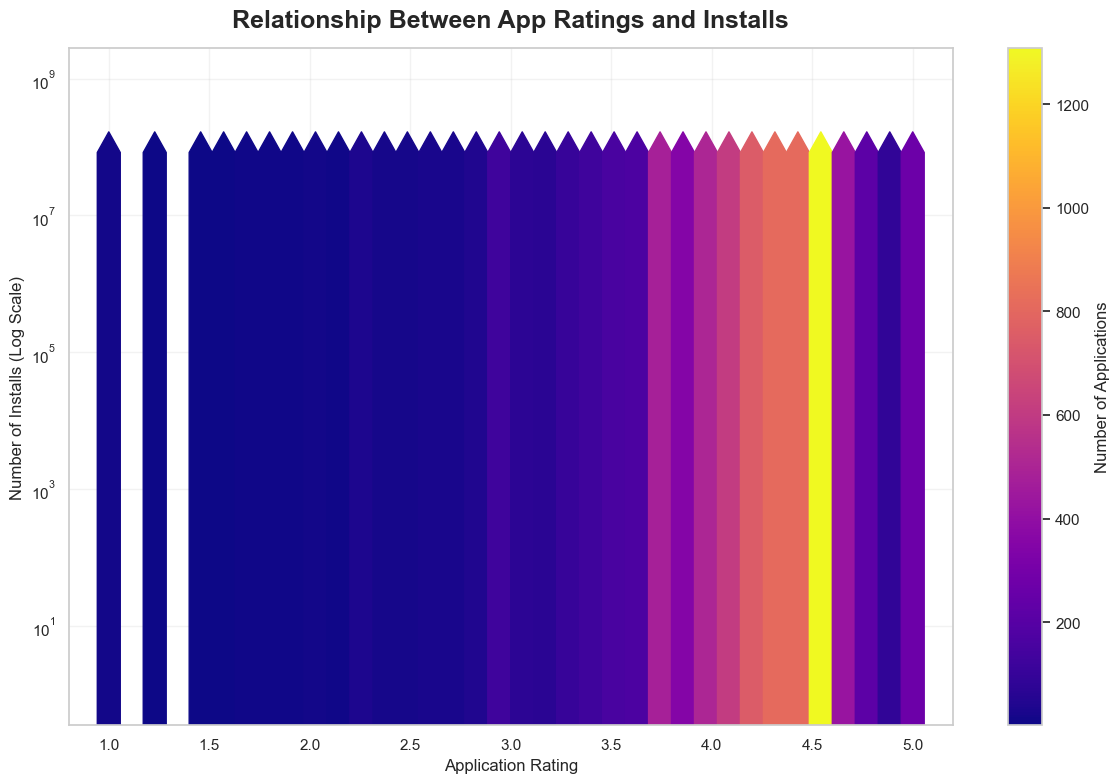

In [19]:
plt.figure(figsize=(12, 8))

plt.hexbin(
    apps_clean_df["Rating"],
    apps_clean_df["Installs_Numeric"],
    gridsize=35,
    cmap="plasma",
    mincnt=1
)

plt.yscale("log")

plt.colorbar(label="Number of Applications")

plt.title(
    "Relationship Between App Ratings and Installs",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Application Rating")
plt.ylabel("Number of Installs (Log Scale)")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

The hexbin plot shows that many applications are clustered between ratings of approximately 4.0 and 4.5. While high-rated applications appear frequently throughout the dataset, high ratings alone do not guarantee a large number of installs.

The relationship between rating and installs appears moderate at best. Ratings may help support application success, but the visualization suggests that popularity is also influenced by other factors such as category, reviews, pricing, and visibility in the app store.

## Visualization 5: Relationship Between Reviews and Installs

User reviews are often considered a measure of user engagement and application popularity. Applications that are downloaded more frequently generally have a greater opportunity to receive user feedback in the form of reviews.

The following visualization explores the relationship between the total number of reviews and the total number of installs. Because both variables span several orders of magnitude, logarithmic scales are applied to improve readability and reveal patterns that would otherwise be compressed.

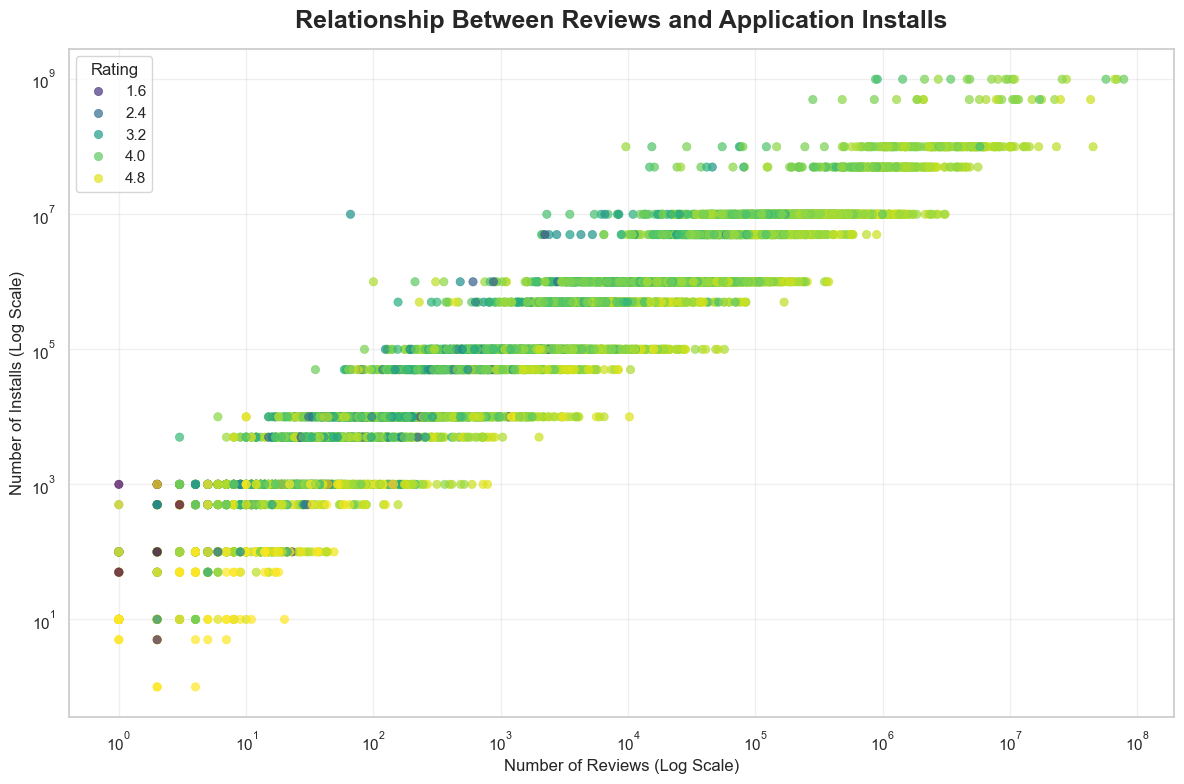

In [20]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=apps_clean_df,
    x="Reviews",
    y="Installs_Numeric",
    hue="Rating",
    palette="viridis",
    alpha=0.7,
    edgecolor=None
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Relationship Between Reviews and Application Installs",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Reviews (Log Scale)")
plt.ylabel("Number of Installs (Log Scale)")

plt.legend(title="Rating")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The visualization reveals a strong positive relationship between the number of reviews and the number of installs. Applications with millions of installs generally receive substantially more user reviews than applications with smaller user bases.

Although higher ratings appear throughout the visualization, the number of reviews shows a much stronger relationship with install count than rating alone. This suggests that user engagement, as measured by review activity, is one of the strongest indicators of application popularity within the Google Play Store dataset.

## Visualization 6: Relationship Between Application Type and Installs

One of the most common questions in mobile application development is whether free applications receive more installs than paid applications. Free applications have a lower barrier to entry, while paid applications rely on users being willing to purchase the app before downloading it.

The following violin plot compares the distribution of install counts for free and paid applications. The violin plot displays both the distribution and density of the data, making it easier to compare how install counts differ between the two pricing models.

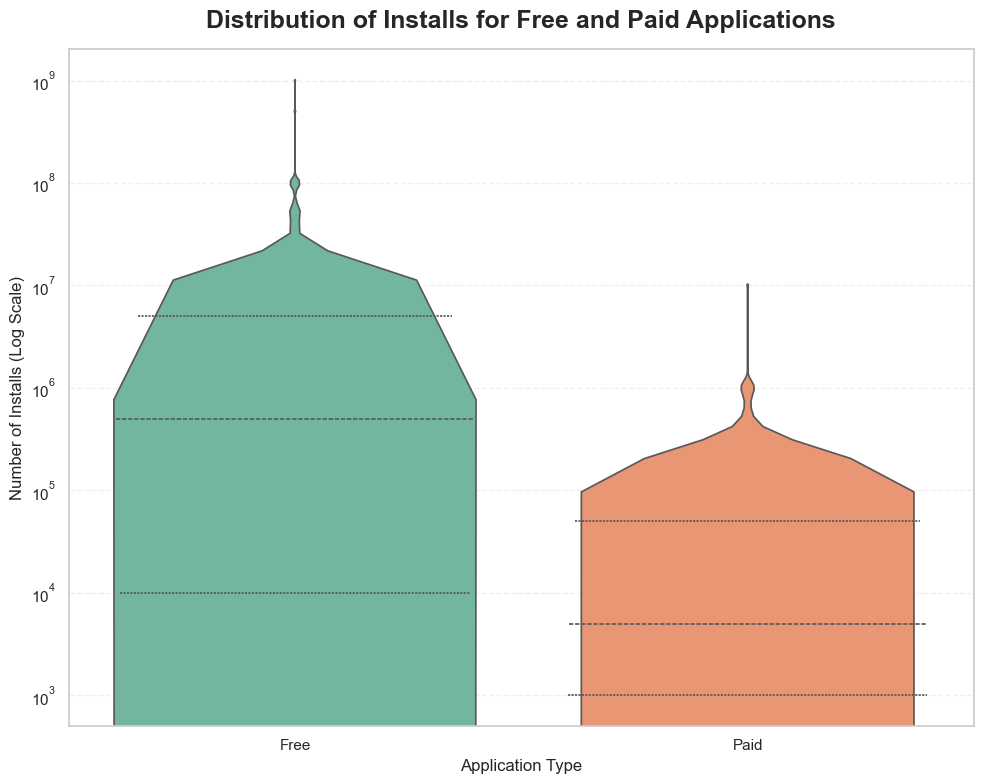

In [21]:
plt.figure(figsize=(10, 8))

sns.violinplot(
    data=apps_clean_df,
    x="Type",
    y="Installs_Numeric",
    hue="Type",
    palette="Set2",
    legend=False,
    inner="quartile"
)

plt.yscale("log")

plt.title(
    "Distribution of Installs for Free and Paid Applications",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Application Type")
plt.ylabel("Number of Installs (Log Scale)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The violin plot shows a clear difference between free and paid applications. Free applications generally have a much wider distribution of install counts and achieve significantly higher numbers of installs than paid applications. This is expected because users can download free applications without an upfront cost, making them more accessible to a broader audience.

Although some paid applications achieve substantial install counts, they represent a much smaller portion of the dataset. Overall, application type appears to have a meaningful relationship with popularity, suggesting that offering an application for free may increase its potential reach within the Google Play Store.

## Visualization 7: Relationship Between Application Price and Installs

While the previous visualization compared free and paid applications, this analysis focuses specifically on application price. Pricing is an important decision for developers because it may influence how many users are willing to download an application.

The following scatter plot explores the relationship between application price and the number of installs. Both axes are displayed using logarithmic scales where appropriate to improve readability and highlight overall trends within the data.

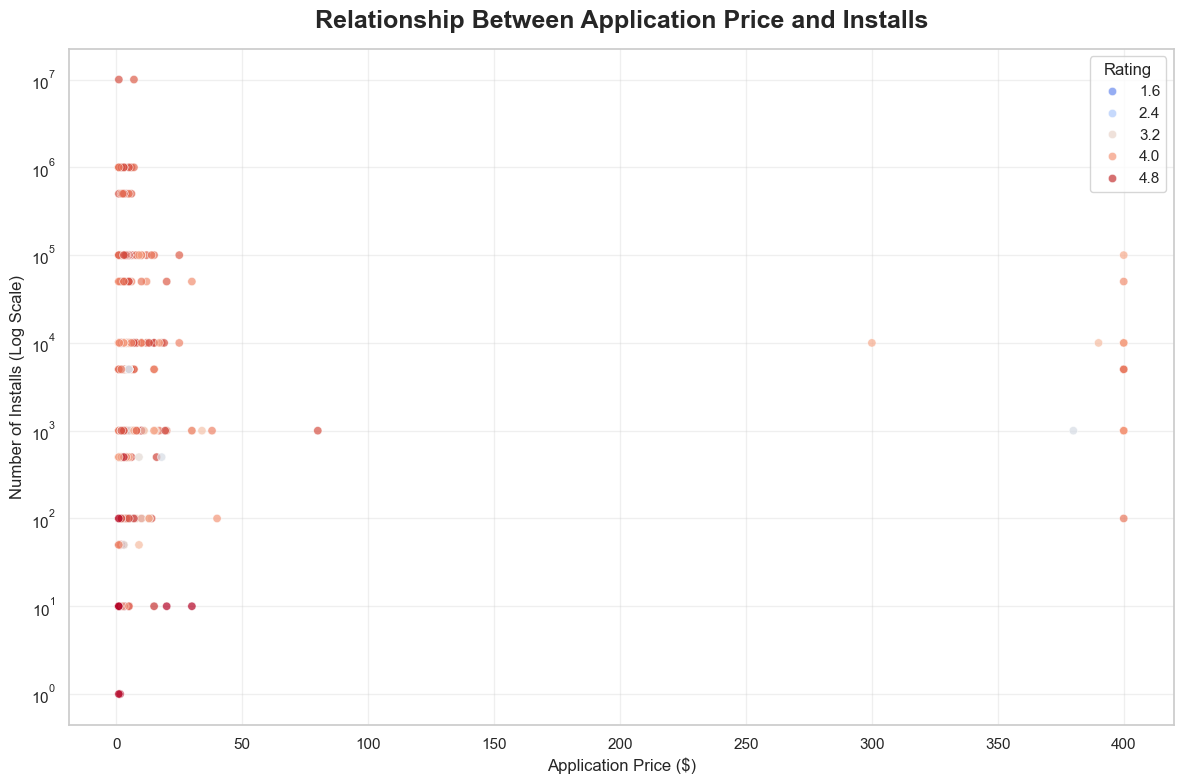

In [22]:
# Only use paid apps since free apps all have a price of $0
paid_apps = apps_clean_df[apps_clean_df["Price"] > 0]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=paid_apps,
    x="Price",
    y="Installs_Numeric",
    hue="Rating",
    palette="coolwarm",
    alpha=0.7
)

plt.yscale("log")

plt.title(
    "Relationship Between Application Price and Installs",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Application Price ($)")
plt.ylabel("Number of Installs (Log Scale)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot suggests that application price has only a weak relationship with the number of installs. While many lower-priced applications achieve large download counts, there are also paid applications across a wide range of prices that receive relatively few installs.

Compared to previous visualizations, price appears to be a less influential factor than application category, user reviews, or whether the application is offered for free. This suggests that users may place greater value on an application's usefulness and reputation than on its purchase price alone.

## Visualization 8: Relationship Between Content Rating and Installs

The intended audience of an application may influence its potential reach within the Google Play Store. Applications rated for everyone have access to a broader audience, while applications intended for teens or adults target smaller user groups.

The following boxplot compares the distribution of install counts across the different content rating categories. This visualization helps determine whether applications designed for broader audiences generally receive more installs than those intended for more specific age groups.

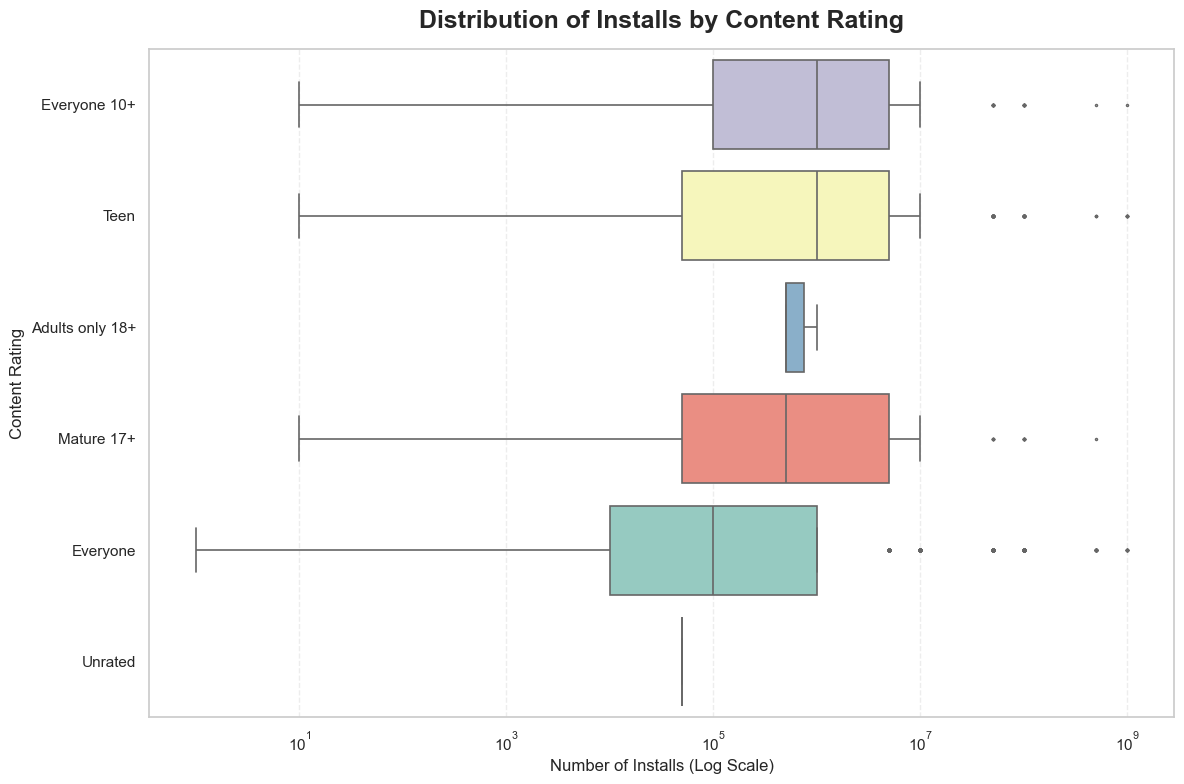

In [23]:
# Order content ratings by median installs
content_order = (
    apps_clean_df.groupby("Content Rating")["Installs_Numeric"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=apps_clean_df,
    x="Installs_Numeric",
    y="Content Rating",
    order=content_order,
    hue="Content Rating",
    palette="Set3",
    legend=False,
    linewidth=1.2,
    fliersize=1.5
)

plt.xscale("log")

plt.title(
    "Distribution of Installs by Content Rating",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Installs (Log Scale)")
plt.ylabel("Content Rating")

plt.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

### Interpretation

The boxplot indicates that applications intended for broader audiences generally achieve higher install counts than applications designed for more restricted age groups. Categories such as **Everyone** and **Everyone 10+** contain many highly downloaded applications, while more restrictive content ratings tend to have lower median install counts.

Although content rating appears to influence application popularity, the differences are not as pronounced as those observed for application category or user reviews. This suggests that content rating contributes to application reach, but it is likely a secondary factor compared to user engagement and application type.

## Visualization 9: Correlation Between Numeric Features

While the previous visualizations examined the relationship between individual features and the target variable, a correlation heatmap provides an overall summary of the relationships among the numeric variables in the dataset.

Correlation coefficients range from **-1** to **1**, where values closer to **1** indicate a strong positive relationship, values closer to **-1** indicate a strong negative relationship, and values near **0** indicate little or no linear relationship. This visualization helps identify which numerical features appear to have the strongest association with application installs.

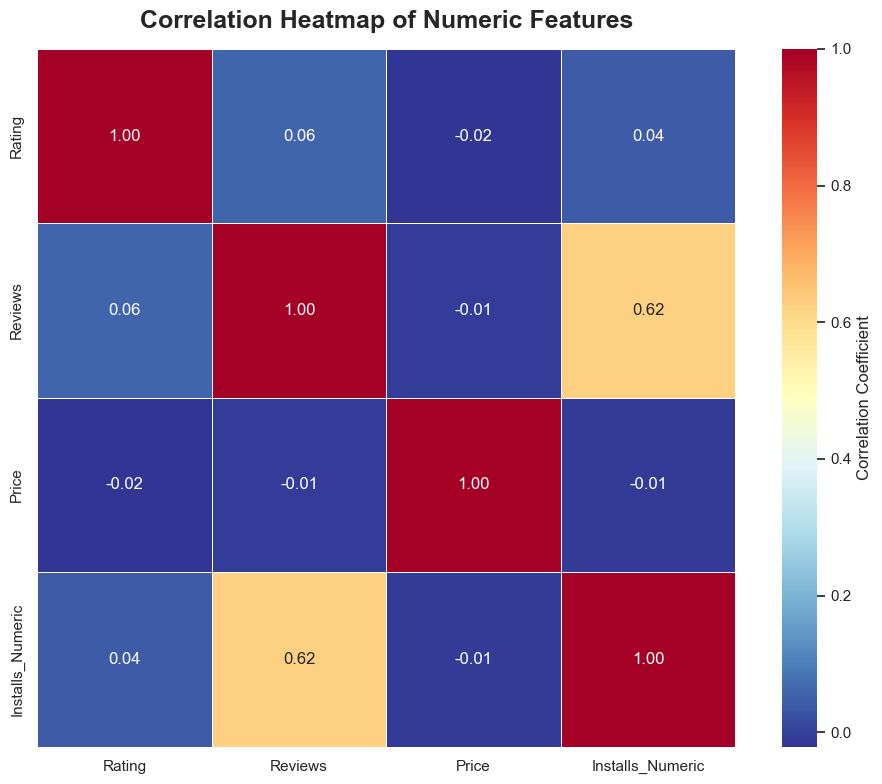

In [24]:
# Select numeric columns for correlation analysis
corr_columns = [
    "Rating",
    "Reviews",
    "Price",
    "Installs_Numeric"
]

corr_matrix = apps_clean_df[corr_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title(
    "Correlation Heatmap of Numeric Features",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

### Interpretation

The correlation heatmap summarizes the strength of the relationships between the numeric variables included in this analysis. As expected, the strongest positive relationship is observed between **Reviews** and **Installs**, indicating that applications with more user reviews generally receive more downloads.

Application **Rating** shows only a weak positive relationship with installs, suggesting that highly rated applications do not necessarily receive substantially more downloads. Likewise, **Price** demonstrates little to no relationship with install count, reinforcing the earlier visualizations that showed pricing alone is not a strong predictor of application popularity.

Overall, the heatmap supports the findings from the previous visualizations by confirming that user engagement, represented by review counts, appears to be one of the strongest indicators of application popularity within this dataset.

## Visualization 10: Bubble Chart of Reviews, Ratings, and Installs

The previous visualizations examined individual relationships between application features and install counts. This final visualization combines several variables into a single figure to provide a broader view of application popularity.

The x-axis represents the number of reviews, the y-axis represents the application rating, the size of each bubble corresponds to the number of installs, and the color distinguishes between free and paid applications. Together, these variables provide a comprehensive summary of how user engagement, ratings, pricing strategy, and popularity interact within the Google Play Store.

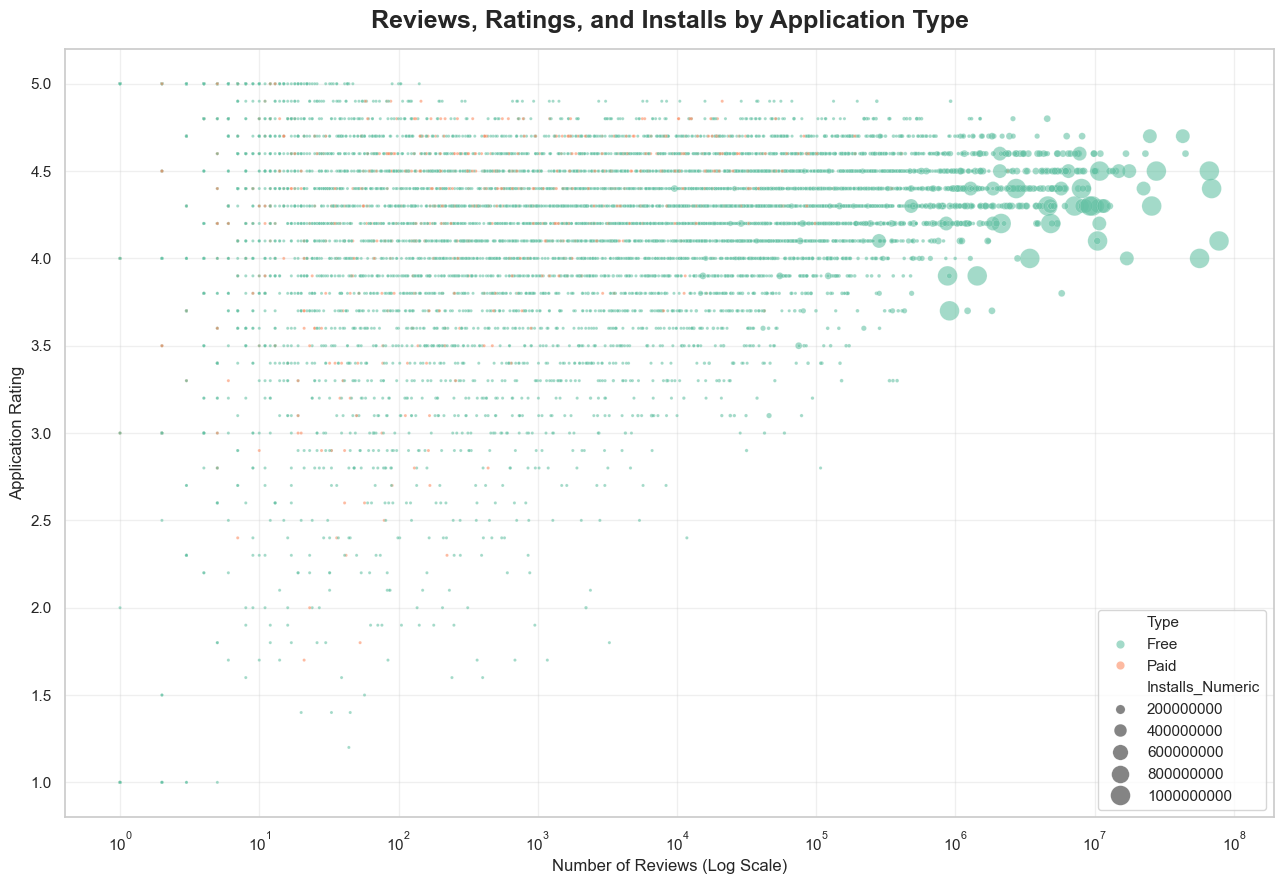

In [26]:
plt.figure(figsize=(13, 9))

sns.scatterplot(
    data=apps_clean_df,
    x="Reviews",
    y="Rating",
    size="Installs_Numeric",
    hue="Type",
    palette="Set2",
    sizes=(5,200),
    alpha=0.6
)

plt.xscale("log")

plt.title(
    "Reviews, Ratings, and Installs by Application Type",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Reviews (Log Scale)")
plt.ylabel("Application Rating")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The bubble chart combines four application characteristics into a single visualization. Larger bubbles represent applications with higher install counts, while the color distinguishes between free and paid applications. Most of the largest bubbles correspond to free applications with high review counts, reinforcing the strong relationship between user engagement and application popularity.

The visualization also demonstrates that high ratings alone are not enough to produce a successful application. Many highly rated applications have relatively few installs, whereas applications with large numbers of reviews generally achieve much higher install counts. This suggests that user engagement, accessibility, and visibility within the Google Play Store have a greater influence on application popularity than rating alone.

# Conclusion

This analysis examined the factors that appear to influence the popularity of Google Play Store applications using the number of installs as the target variable. Six application characteristics were compared to install counts through a variety of visualizations, including histograms, boxplots, bar charts, scatter plots, violin plots, heatmaps, and bubble charts.

## Features Most Related to Application Popularity

Based on the visualizations, **Category** and **Reviews** demonstrated the strongest relationships with application installs. Certain categories consistently achieved higher install counts than others, indicating that the type of application plays an important role in determining potential audience size. The number of user reviews also showed a strong positive relationship with installs, suggesting that highly downloaded applications naturally generate greater user engagement.

Application **Type** (Free versus Paid) also displayed a meaningful relationship with installs. Free applications generally reached substantially larger audiences than paid applications, likely because users can download them without an upfront cost.

## Features with Moderate or Weak Relationships

Application **Rating** showed only a moderate relationship with install counts. While many highly downloaded applications maintained ratings between 4.0 and 4.7, there were also many highly rated applications with relatively few installs. This suggests that high ratings alone are not enough to guarantee application popularity.

**Content Rating** demonstrated a modest relationship with installs. Applications intended for broader audiences generally achieved higher download counts than those designed for more restricted audiences, although the effect was less pronounced than category or review count.

Application **Price** appeared to have the weakest relationship with installs. While lower-priced applications often received more downloads, pricing alone was not a reliable predictor of application popularity.

## Overall Findings

The visualizations indicate that application popularity is influenced by multiple factors rather than a single characteristic. Among the features analyzed, user engagement (measured by review count) and application category demonstrated the strongest relationships with install counts, while application price showed the weakest relationship. Free applications also tended to reach larger audiences than paid applications, and high user ratings alone were not a reliable predictor of popularity.

Overall, the results suggest that success on the Google Play Store is driven more by user engagement, accessibility, and market demand than by price or rating alone. Developers seeking to maximize application popularity should focus on creating high-quality applications that encourage user interaction, appeal to broad audiences when appropriate, and minimize barriers to adoption.